In [1]:
import pandas as pd

In [2]:
#!python 1.run_embeddings.py
#!python 2.pca_vs_umap_vs_autoencoder.py --embedding_file 'H3BERTA_50KNAIVE_50KMEMORY_OAS_PAIRED_RANDOMLY_SELECTED_embeddings.pkl'  --hue_class locus_light --output_appendix antiBERTa

In [2]:
# Percorso al file CSV specifico
DATA_PATH = "../../50knaive_50kmemory_oas_paired_randomly_selected.csv"

# (Opzionale) Colonne attese, se vuoi forzare qualcosa
columns = [
    "sequence_heavy",
    "locus_heavy",
    "v_call_heavy",
    "sequence_alignment_heavy",
    "sequence_alignment_aa_heavy",
    "germline_alignment_aa_heavy",
    "cdr3_aa_heavy",
    "sequence_light",
    "locus_light",
    "v_call_light",
    "sequence_alignment_light",
    "sequence_alignment_aa_light",
    "germline_alignment_aa_light",
    "cdr3_aa_light",
    "sequence_alignment_heavy_sep_light",
    "BType",
    "Disease",
    "Species",
]


# Legge direttamente il CSV specificato
df = pd.read_csv(DATA_PATH, header=0)
(df.head(2))

,sequence_heavy,locus_heavy,v_call_heavy,sequence_alignment_heavy,sequence_alignment_aa_heavy,germline_alignment_aa_heavy,cdr3_aa_heavy,sequence_light,locus_light,v_call_light,sequence_alignment_light,sequence_alignment_aa_light,germline_alignment_aa_light,cdr3_aa_light,sequence_alignment_heavy_sep_light,BType,Disease,Species
0,ACTTTCTGAGAGTCCTGGACCTCCTGTGCAAGAACATGAGACATCT...,H,IGHV4-59*02,CAGGTGCACCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,QVHLQESGPGLVRPSETLSLTCTVSGGSVSSSYWSWIRQSPGKGLE...,QVQLQESGPGLVKPSETLSLTCTVSGGSVSSYYWSWIRQPPGKGLE...,ANSGFYEKFDY,AGAGCTCTGGAGAAGAGCTGCTCAGTTAGGACCCAGAGGGAACCAT...,K,IGKV3-20*01,GAAATTGTGTTGACGCAGTCTCCAGGCACCCTGTCTTTGTCTGCAG...,EIVLTQSPGTLSLSAGERATLSCRASQSVSGSYLAWYQQKPGQAPR...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QQYGDSPLT,QVHLQESGPGLVRPSETLSLTCTVSGGSVSSSYWSWIRQSPGKGLE...,Memory-B-Cells,CMV,human
1,GGGGGCTTTCTGAGAGTCATGGACCTCCTGTGCAAGAACATGAAGC...,H,IGHV4-38-2*02,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGG...,QVQLQESGPGLVKPSETLSLTCAVSGFSLSSGFYWGWMRQPPGKGL...,QVQLQESGPGLVKPSETLSLTCTVSGYSISSGYYWGWIRQPPGKGL...,ARERGGVIAATCMDV,GGCTGGGGTCTCAGGAGGCAGCACTCTCGGGACGTCTCCACCATGG...,L,IGLV2-11*01,CAGTCTGCCCTGACTCAGCCTCGCTCAGTGTCCGGGTCTCCTGGAC...,QSALTQPRSVSGSPGQSVTISCSGTSSDVGGYDFVSWYQQHPDKAP...,QSALTQPRSVSGSPGQSVTISCTGTSSDVGGYNYVSWYQQHPGKAP...,CSFAGRYTFRV,QVQLQESGPGLVKPSETLSLTCAVSGFSLSSGFYWGWMRQPPGKGL...,Memory-B-Cells,NaN,human


In [3]:
from plots_utils import *

Sto caricando: ./out_embeddings/PCA_H3BERTA_50KNAIVE_50KMEMORY_OAS_PAIRED_RANDOMLY_SELECTED PCA embeddings.csv


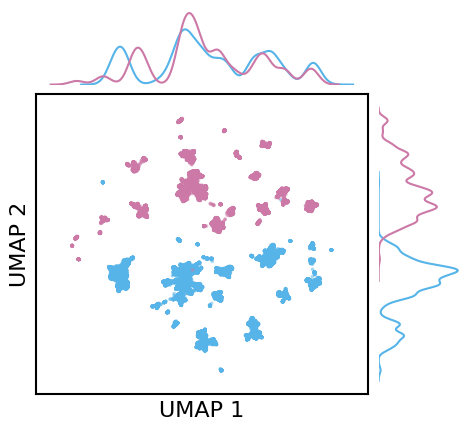

<Figure size 300x100 with 0 Axes>

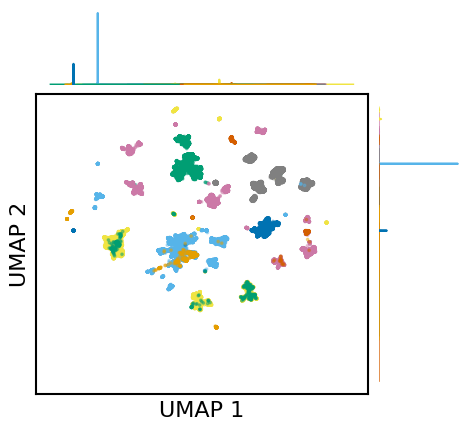

<Figure size 300x100 with 0 Axes>

In [4]:
# random selection
import glob
import random
import pandas as pd

# 1. Crea la lista di tutti i CSV che terminano con "PCA embeddings.csv"
file_list = glob.glob("./out_embeddings/*PCA embeddings.csv")

# 2. Sceglie casualmente un file dalla lista
file_path = random.choice(file_list)
print(f"Sto caricando: {file_path}")

# 3. Legge il CSV scelto
df = pd.read_csv(file_path)

# 4. Normalizza le colonne come facevi già
for col in ['v_call_light']:
    df[col] = (
        df[col].astype(str)
               .str.split('/', n=1).str[0]
               .str.split('-', n=1).str[0]
    )

# 5. Plotta
plot_umap_single_gene_INSCAPE(df, gene_col='locus_light', title='locus_light', file_suffix="./img/CDR3L")
plot_umap_single_gene_INSCAPE(df, gene_col='v_call_light', title='V gene', file_suffix="./img/CDR3L")